COMPARISON OF ACTIVATION FUNCTIONS FOR BEAM DEFLECTION

Solving with tanh activation...
  Error: 0.8384% | Max error: 0.018353 | β₀: -15.614545

Solving with Gaussian activation...
  Error: 0.0780% | Max error: 0.001683 | β₀: -0.343308

Solving with sigmoid activation...
  Error: 0.9514% | Max error: 0.018806 | β₀: 125.251892


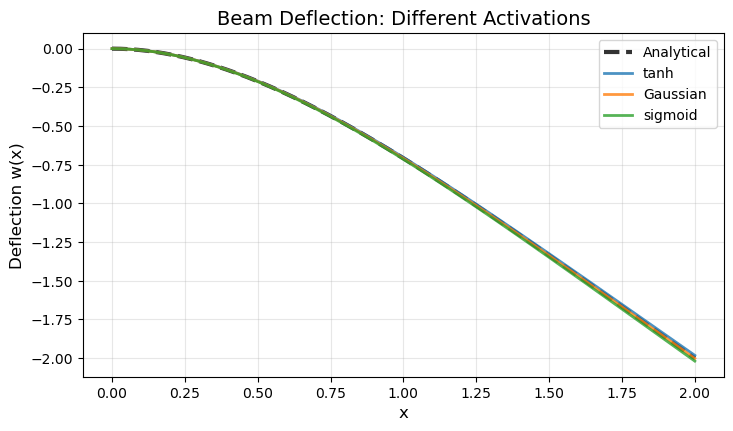

In [2]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer
import numpy as np

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# COMMON SETUP
# =============================================================================
torch.manual_seed(42)
hidden_size = 40
n_collocation = 100
n_pred = 200

# =============================================================================
# ACTIVATION FUNCTIONS
# =============================================================================
def hidden_layer_tanh(x, W, b):
    """tanh activation"""
    H = torch.tanh(x @ W + b)
    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H], dim=1)

def hidden_layer_gaussian(x, W, b):
    """Gaussian activation"""
    H = torch.exp(-(x @ W + b)**2)
    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H], dim=1)

def hidden_layer_sigmoid(x, W, b):
    """Sigmoid activation"""
    H = torch.sigmoid(x @ W + b)
    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H], dim=1)

# =============================================================================
# PIELM SOLVER WITH PENALTY METHOD
# =============================================================================
def solve_pielm(activation_func, activation_name, lambda_values):
    """Solve beam problem with given activation function"""
    print(f"\nSolving with {activation_name} activation...")
    
    # Initialize weights for this activation
    W = torch.randn(1, hidden_size)
    b = torch.randn(hidden_size)
    
    # Collocation points
    x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
    x_0 = torch.tensor([[0.0]], requires_grad=True)
    x_L = torch.tensor([[L]], requires_grad=True)
    
    # Build PDE matrix A
    H_c = activation_func(x_c, W, b)
    A_cols = []
    
    # β₀ term
    zero_col = torch.zeros(n_collocation, 1)
    A_cols.append(zero_col)
    
    # β₁ to β₄₀ terms
    for j in range(1, hidden_size + 1):
        wj = H_c[:, j:j+1]
        w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
        w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
        w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
        w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
        A_cols.append(w_xxxx)
    
    A = E * I * torch.hstack(A_cols)
    b_pde = Q * torch.ones(n_collocation, 1)
    
    # Build boundary constraint matrices
    def bc_row(x, order):
        H = activation_func(x, W, b)
        row = []
        
        if order == 0:
            row.append(torch.ones(1, 1))
        else:
            row.append(torch.zeros(1, 1))
        
        for j in range(1, hidden_size + 1):
            w = H[:, j:j+1]
            for _ in range(order):
                w = autograd.grad(w.sum(), x, create_graph=True)[0]
            row.append(w)
        
        return torch.hstack(row)
    
    C0 = bc_row(x_0, 0)   # w(0) = 0
    C1 = bc_row(x_0, 1)   # w'(0) = 0
    C2 = bc_row(x_L, 2)   # w''(L) = 0
    C3 = bc_row(x_L, 3)   # w'''(L) = 0
    
    # Extract λ values
    lambda1, lambda2, lambda3, lambda4 = lambda_values
    
    # Build augmented system
    M = A.T @ A
    M += lambda1 * (C0.T @ C0)
    M += lambda2 * (C1.T @ C1)
    M += lambda3 * (C2.T @ C2)
    M += lambda4 * (C3.T @ C3)
    
    rhs = A.T @ b_pde
    
    # Add small regularization
    alpha = 1e-8 * torch.trace(M) / (hidden_size + 1)
    M += alpha * torch.eye(hidden_size + 1)
    
    # Solve
    beta = torch.linalg.solve(M, rhs)
    
    # Prediction
    x_pred = torch.linspace(0, L, n_pred).view(-1, 1)
    H_pred = activation_func(x_pred, W, b)
    w_pred = H_pred @ beta
    w_exact = analytical_solution(x_pred)
    
    # Calculate relative error percentage
    rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.mean(torch.abs(w_exact))
    error_percentage = rel_error.item() * 100
    
    # Calculate max error
    max_error = torch.max(torch.abs(w_pred - w_exact)).item()
    
    return w_pred.detach(), w_exact.detach(), error_percentage, max_error, beta[0].item()

# =============================================================================
# MAIN COMPARISON
# =============================================================================
print("="*70)
print("COMPARISON OF ACTIVATION FUNCTIONS FOR BEAM DEFLECTION")
print("="*70)

# Common λ values for all activations
lambda_values = [10000, 100, 100, 100]  # w(0), w'(0), w''(L), w'''(L)

# Store results
results = {}

# Solve for each activation
activations = [
    ("tanh", hidden_layer_tanh),
    ("Gaussian", hidden_layer_gaussian),
    ("sigmoid", hidden_layer_sigmoid)
]

for activation_name, activation_func in activations:
    w_pred, w_exact, error_pct, max_err, beta0 = solve_pielm(
        activation_func, activation_name, lambda_values
    )
    results[activation_name] = {
        'prediction': w_pred,
        'exact': w_exact,
        'error_percentage': error_pct,
        'max_error': max_err,
        'beta0': beta0
    }
    print(f"  Error: {error_pct:.4f}% | Max error: {max_err:.6f} | β₀: {beta0:.6f}")

# =============================================================================
# COMPARISON PLOT
# =============================================================================
x_pred = torch.linspace(0, L, n_pred).view(-1, 1)

plt.figure(figsize=(14, 8))

# Plot 1: Deflection comparison
plt.subplot(2, 2, 1)
plt.plot(x_pred.numpy(), results['tanh']['exact'].numpy(), 'k--', 
         linewidth=3, label='Analytical', alpha=0.8)
for name in ['tanh', 'Gaussian', 'sigmoid']:
    plt.plot(x_pred.numpy(), results[name]['prediction'].numpy(), 
             linewidth=2, label=name, alpha=0.8)
plt.xlabel('x', fontsize=12)
plt.ylabel('Deflection w(x)', fontsize=12)
plt.title('Beam Deflection: Different Activations', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()



KKT vs PENALTY FOR GAUSSIAN ACTIVATION
Building matrices...

Solving with KKT...
  Error: 0.0069%
  Time: 0.0022s

Solving with Penalty (λ=10000)...
  Error: 0.3435%
  Time: 0.0002s

Solving with Penalty (λ=1000)...
  Error: 0.1301%
  Time: 0.0002s

Solving with Penalty (λ=100)...
  Error: 0.1339%
  Time: 0.0003s


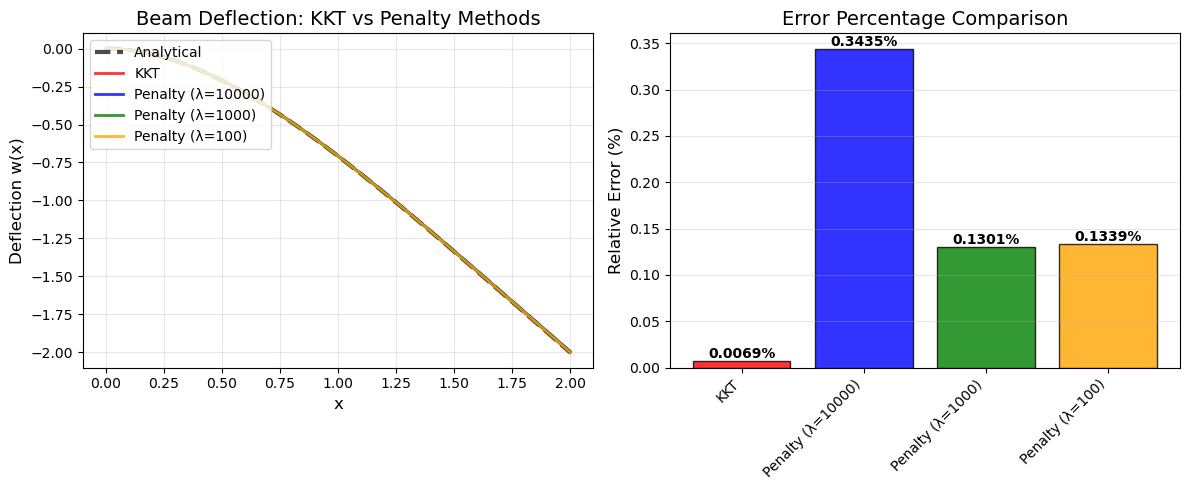


RESULTS SUMMARY
Method                    Error %         Time (s)  
--------------------------------------------------

RESULTS SUMMARY
Method                    Error %         Time (s)  
--------------------------------------------------
KKT                       0.006918        0.0022    
Penalty (λ=10000)         0.343515        0.0002    
Penalty (λ=1000)          0.130102        0.0002    
Penalty (λ=100)           0.133930        0.0003    


In [5]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer
import numpy as np

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# GAUSSIAN ACTIVATION FUNCTION
# =============================================================================
torch.manual_seed(42)

def hidden_layer_gaussian(x, W, b):
    """Gaussian activation: exp(-(Wx + b)^2)"""
    H_gaussian = torch.exp(-(x @ W + b)**2)
    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H_gaussian], dim=1)

# =============================================================================
# COMMON SETUP
# =============================================================================
hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)
n_collocation = 100
n_pred = 200

# Collocation points
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD COMMON MATRICES
# =============================================================================
def build_matrices():
    H_c = hidden_layer_gaussian(x_c, W, b)
    A_cols = []
    
    # β₀ term
    zero_col = torch.zeros(n_collocation, 1)
    A_cols.append(zero_col)
    
    # β₁ to β₄₀ terms
    for j in range(1, hidden_size + 1):
        wj = H_c[:, j:j+1]
        w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
        w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
        w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
        w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
        A_cols.append(w_xxxx)
    
    A = E * I * torch.hstack(A_cols)
    b_pde = Q * torch.ones(n_collocation, 1)
    
    # Build boundary constraint matrices
    def bc_row(x, order):
        H = hidden_layer_gaussian(x, W, b)
        row = []
        
        if order == 0:
            row.append(torch.ones(1, 1))
        else:
            row.append(torch.zeros(1, 1))
        
        for j in range(1, hidden_size + 1):
            w = H[:, j:j+1]
            for _ in range(order):
                w = autograd.grad(w.sum(), x, create_graph=True)[0]
            row.append(w)
        
        return torch.hstack(row)
    
    C = torch.vstack([
        bc_row(x_0, 0),   # w(0) = 0
        bc_row(x_0, 1),   # w'(0) = 0
        bc_row(x_L, 2),   # w''(L) = 0
        bc_row(x_L, 3)    # w'''(L) = 0
    ])
    
    d = torch.zeros(4, 1)
    
    return A, b_pde, C, d

# =============================================================================
# KKT METHOD
# =============================================================================
def solve_with_KKT(A, b_pde, C, d):
    total_beta = hidden_size + 1
    total_unknowns = total_beta + 4
    
    KKT = torch.zeros(total_unknowns, total_unknowns)
    KKT[:total_beta, :total_beta] = A.T @ A
    KKT[:total_beta, total_beta:] = C.T
    KKT[total_beta:, :total_beta] = C
    
    rhs = torch.vstack([A.T @ b_pde, d])
    
    alpha = 1e-8 * torch.trace(A.T @ A) / total_beta
    KKT += alpha * torch.eye(total_unknowns)
    
    solution = torch.linalg.solve(KKT, rhs)
    beta = solution[:total_beta]
    
    return beta

# =============================================================================
# PENALTY METHOD
# =============================================================================
def solve_with_penalty(A, b_pde, C, d, lambda_values):
    lambda1, lambda2, lambda3, lambda4 = lambda_values
    
    C0 = C[0:1, :]   # w(0) = 0
    C1 = C[1:2, :]   # w'(0) = 0
    C2 = C[2:3, :]   # w''(L) = 0
    C3 = C[3:4, :]   # w'''(L) = 0
    
    M = A.T @ A
    M += lambda1 * (C0.T @ C0)
    M += lambda2 * (C1.T @ C1)
    M += lambda3 * (C2.T @ C2)
    M += lambda4 * (C3.T @ C3)
    
    rhs = A.T @ b_pde
    
    alpha = 1e-8 * torch.trace(M) / (hidden_size + 1)
    M += alpha * torch.eye(hidden_size + 1)
    
    beta = torch.linalg.solve(M, rhs)
    
    return beta

# =============================================================================
# ERROR CALCULATION
# =============================================================================
def calculate_errors(beta):
    x_pred = torch.linspace(0, L, n_pred).view(-1, 1)
    H_pred = hidden_layer_gaussian(x_pred, W, b)
    w_pred = H_pred @ beta
    w_exact = analytical_solution(x_pred)
    
    rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.mean(torch.abs(w_exact))
    error_percentage = rel_error.item() * 100
    
    return {
        'prediction': w_pred.detach(),
        'exact': w_exact.detach(),
        'error_percentage': error_percentage
    }

# =============================================================================
# MAIN COMPARISON
# =============================================================================
print("="*70)
print("KKT vs PENALTY FOR GAUSSIAN ACTIVATION")
print("="*70)

# Build common matrices
print("Building matrices...")
A, b_pde, C, d = build_matrices()

# Test configurations
configs = [
    {"name": "KKT", "lambda": None, "solver": solve_with_KKT},
    {"name": "Penalty (λ=10000)", "lambda": [10000, 100, 100, 100], "solver": solve_with_penalty},
    {"name": "Penalty (λ=1000)", "lambda": [1000, 100, 100, 100], "solver": solve_with_penalty},
    {"name": "Penalty (λ=100)", "lambda": [100, 100, 100, 100], "solver": solve_with_penalty},
]

# Store results
results = {}

for config in configs:
    print(f"\nSolving with {config['name']}...")
    t0 = default_timer()
    
    if config['name'] == "KKT":
        beta = config['solver'](A, b_pde, C, d)
    else:
        beta = config['solver'](A, b_pde, C, d, config['lambda'])
    
    results[config['name']] = calculate_errors(beta)
    results[config['name']]['time'] = default_timer() - t0
    
    print(f"  Error: {results[config['name']]['error_percentage']:.4f}%")
    print(f"  Time: {results[config['name']]['time']:.4f}s")

# =============================================================================
# PLOT 1: BEAM DEFLECTION COMPARISON
# =============================================================================
x_pred = torch.linspace(0, L, n_pred).view(-1, 1)

plt.figure(figsize=(12, 5))

# Beam Deflection Plot
plt.subplot(1, 2, 1)
plt.plot(x_pred.numpy(), results['KKT']['exact'].numpy(), 'k--', 
         linewidth=3, label='Analytical', alpha=0.7)

# Colors for different methods
colors = ['red', 'blue', 'green', 'orange']
line_styles = ['-', '-', '-', '-']

for idx, (method, color, style) in enumerate(zip(configs, colors, line_styles)):
    plt.plot(x_pred.numpy(), results[method['name']]['prediction'].numpy(), 
             color=color, linestyle=style, linewidth=2, label=method['name'], alpha=0.8)

plt.xlabel('x', fontsize=12)
plt.ylabel('Deflection w(x)', fontsize=12)
plt.title('Beam Deflection: KKT vs Penalty Methods', fontsize=14)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# =============================================================================
# PLOT 2: RELATIVE ERROR PERCENTAGE COMPARISON
# =============================================================================
plt.subplot(1, 2, 2)

methods = [config['name'] for config in configs]
error_pcts = [results[method]['error_percentage'] for method in methods]

bars = plt.bar(methods, error_pcts, color=colors, alpha=0.8, edgecolor='black')
plt.ylabel('Relative Error (%)', fontsize=12)
plt.title('Error Percentage Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add value labels on bars
for bar, error in zip(bars, error_pcts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, 
             f'{error:.4f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# =============================================================================
# RESULTS TABLE
# =============================================================================
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"{'Method':<25} {'Error %':<15} {'Time (s)':<10}")
print("-"*50)
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"{'Method':<25} {'Error %':<15} {'Time (s)':<10}")
print("-"*50)

for config in configs:
    method = config['name']
    res = results[method]
    print(f"{method:<25} {res['error_percentage']:<15.6f} {res['time']:<10.4f}")



Solving with tanh activation...
Solving with sigmoid activation...
Solving with gaussian activation...

Activation     Relative Error (%)  
tanh           0.027652            
sigmoid        0.005808            
gaussian       0.006918            


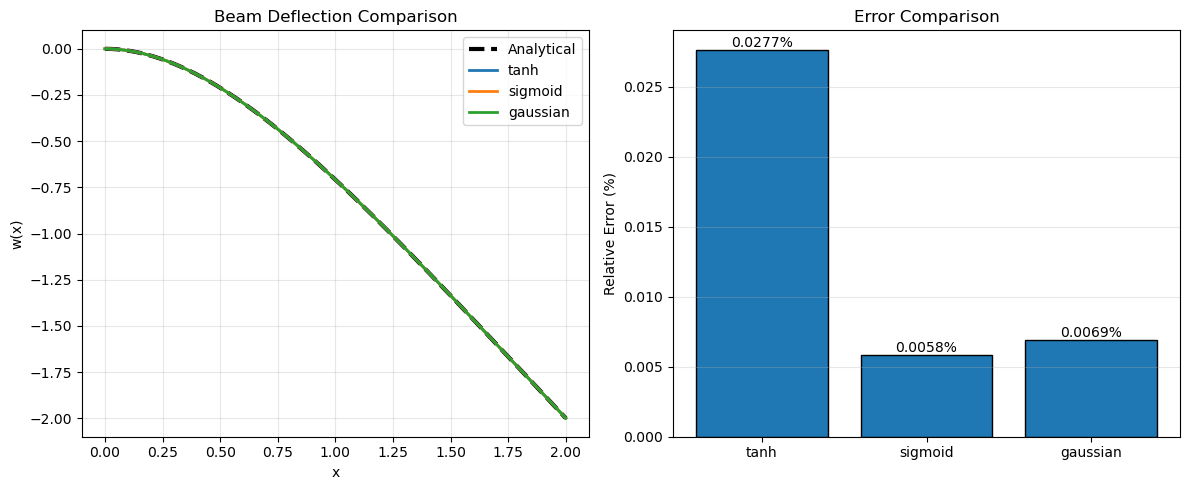

In [1]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

torch.manual_seed(42)

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4 * L * x + 6 * L**2)

# =============================================================================
# ACTIVATION FUNCTIONS
# =============================================================================
def hidden_layer(x, W, b, activation="tanh"):
    z = x @ W + b

    if activation == "tanh":
        H = torch.tanh(z)
    elif activation == "sigmoid":
        H = torch.sigmoid(z)
    elif activation == "gaussian":
        H = torch.exp(-z**2)
    else:
        raise ValueError("Unsupported activation")

    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H], dim=1)

# =============================================================================
# COMMON SETUP
# =============================================================================
hidden_size = 40
n_collocation = 100
n_pred = 200

W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD MATRICES
# =============================================================================
def build_matrices(activation):
    H_c = hidden_layer(x_c, W, b, activation)
    A_cols = []

    # beta_0 term -> derivative is zero
    A_cols.append(torch.zeros(n_collocation, 1))

    # hidden neuron terms
    for j in range(1, hidden_size + 1):
        wj = H_c[:, j:j+1]
        w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
        w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
        w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
        w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
        A_cols.append(w_xxxx)

    A = E * I * torch.hstack(A_cols)
    b_pde = Q * torch.ones(n_collocation, 1)

    def bc_row(x, order):
        H = hidden_layer(x, W, b, activation)
        row = []

        if order == 0:
            row.append(torch.ones(1, 1))   # beta_0 contributes to w
        else:
            row.append(torch.zeros(1, 1))  # beta_0 derivative is zero

        for j in range(1, hidden_size + 1):
            w = H[:, j:j+1]
            for _ in range(order):
                w = autograd.grad(w.sum(), x, create_graph=True)[0]
            row.append(w)

        return torch.hstack(row)

    # Boundary conditions:
    # w(0)=0, w'(0)=0, w''(L)=0, w'''(L)=0
    C = torch.vstack([
        bc_row(x_0, 0),
        bc_row(x_0, 1),
        bc_row(x_L, 2),
        bc_row(x_L, 3)
    ])

    d = torch.zeros(4, 1)

    return A, b_pde, C, d

# =============================================================================
# KKT SOLVER
# =============================================================================
def solve_with_KKT(A, b_pde, C, d):
    n_beta = hidden_size + 1
    n_constraints = C.shape[0]

    KKT = torch.zeros(n_beta + n_constraints, n_beta + n_constraints)
    KKT[:n_beta, :n_beta] = A.T @ A
    KKT[:n_beta, n_beta:] = C.T
    KKT[n_beta:, :n_beta] = C

    rhs = torch.vstack([A.T @ b_pde, d])

    # small regularization
    alpha = 1e-8 * torch.trace(A.T @ A) / n_beta
    KKT += alpha * torch.eye(n_beta + n_constraints)

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:n_beta]

    return beta

# =============================================================================
# PREDICTION + ERROR
# =============================================================================
def predict_and_error(beta, activation):
    x_pred = torch.linspace(0, L, n_pred).view(-1, 1)
    H_pred = hidden_layer(x_pred, W, b, activation)
    w_pred = H_pred @ beta
    w_exact = analytical_solution(x_pred)

    rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.mean(torch.abs(w_exact))
    return x_pred.detach(), w_pred.detach(), w_exact.detach(), rel_error.item() * 100

# =============================================================================
# MAIN
# =============================================================================
activations = ["tanh", "sigmoid", "gaussian"]
results = {}

for act in activations:
    print(f"Solving with {act} activation...")
    A, b_pde, C, d = build_matrices(act)
    beta = solve_with_KKT(A, b_pde, C, d)
    x_pred, w_pred, w_exact, error_pct = predict_and_error(beta, act)

    results[act] = {
        "x": x_pred,
        "prediction": w_pred,
        "exact": w_exact,
        "error_pct": error_pct
    }

# =============================================================================
# PRINT RESULTS
# =============================================================================
print("\n" + "=" * 55)
print(f"{'Activation':<15}{'Relative Error (%)':<20}")
print("=" * 55)
for act in activations:
    print(f"{act:<15}{results[act]['error_pct']:<20.6f}")

# =============================================================================
# PLOT 1: SOLUTION COMPARISON
# =============================================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    results["tanh"]["x"].numpy(),
    results["tanh"]["exact"].numpy(),
    "k--",
    linewidth=3,
    label="Analytical"
)

plt.plot(results["tanh"]["x"].numpy(), results["tanh"]["prediction"].numpy(), label="tanh", linewidth=2)
plt.plot(results["sigmoid"]["x"].numpy(), results["sigmoid"]["prediction"].numpy(), label="sigmoid", linewidth=2)
plt.plot(results["gaussian"]["x"].numpy(), results["gaussian"]["prediction"].numpy(), label="gaussian", linewidth=2)

plt.xlabel("x")
plt.ylabel("w(x)")
plt.title("Beam Deflection Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# =============================================================================
# PLOT 2: ERROR COMPARISON
# =============================================================================
plt.subplot(1, 2, 2)
labels = activations
errors = [results[a]["error_pct"] for a in labels]

bars = plt.bar(labels, errors, edgecolor="black")
plt.ylabel("Relative Error (%)")
plt.title("Error Comparison")
plt.grid(True, axis="y", alpha=0.3)

for bar, err in zip(bars, errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{err:.4f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Solving with tanh activation...
Solving with sigmoid activation...
Solving with gaussian activation...

Activation     Relative Error (%)  Max Error           Time (s)       
tanh           0.028192            6.051064e-04        0.118809       
sigmoid        0.003459            7.772446e-05        0.016677       
gaussian       0.001194            3.886223e-05        0.027034       


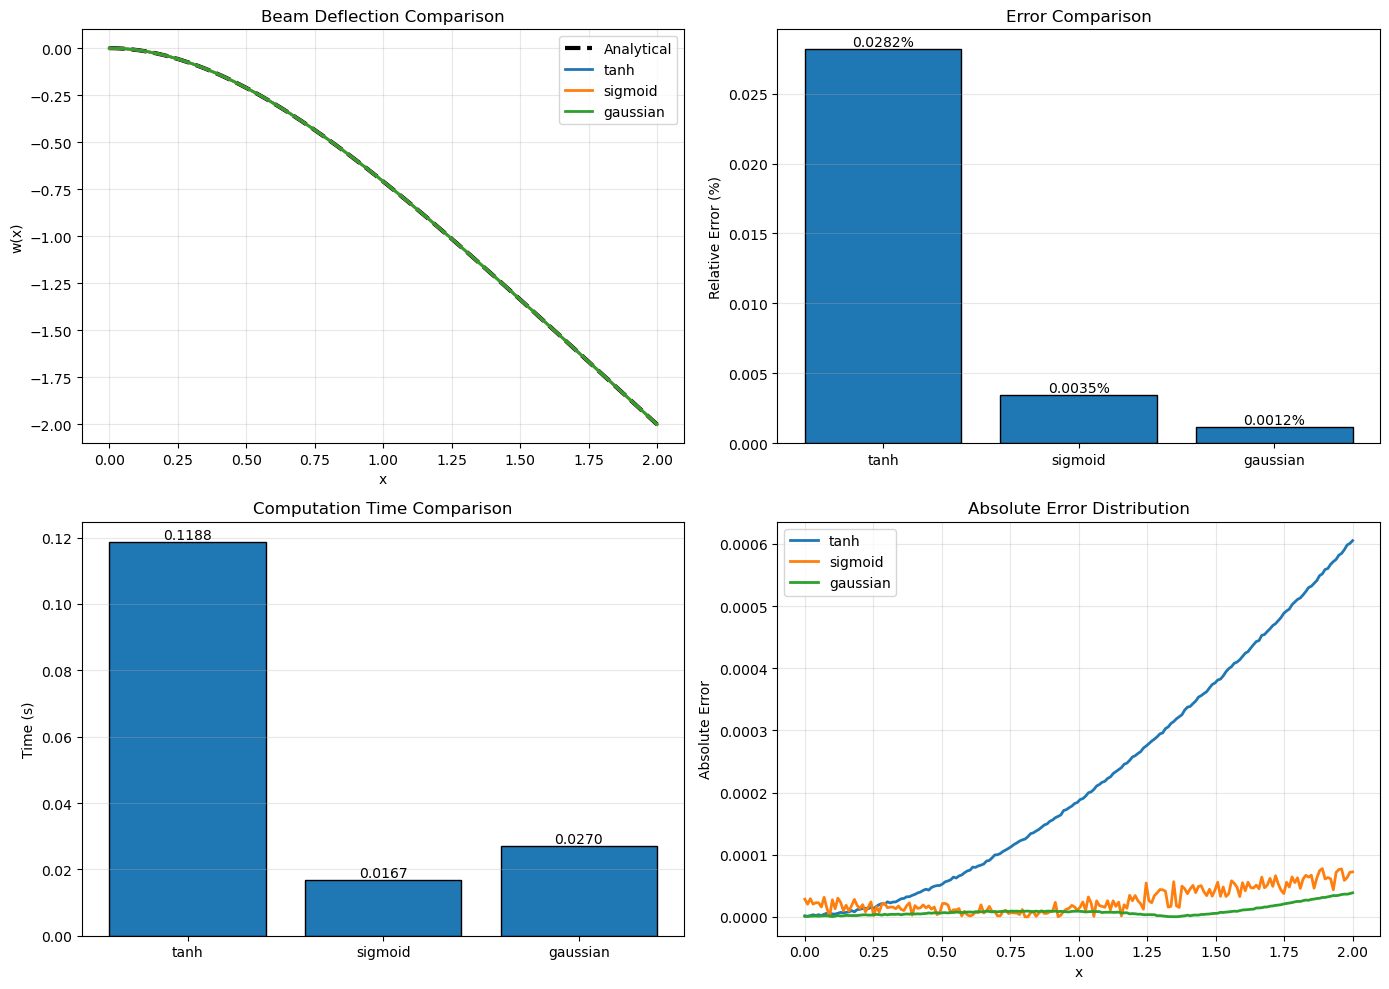


ADDITIONAL DIAGNOSTIC INFORMATION

Activation: tanh
  Regularization alpha: 8.536316e-05
  beta_0: 0.064240
  ||lambda||_2: 5.410344e-02

Activation: sigmoid
  Regularization alpha: 1.623665e-07
  beta_0: 7.512177
  ||lambda||_2: 5.626025e-03

Activation: gaussian
  Regularization alpha: 6.091848e-04
  beta_0: -3.988521
  ||lambda||_2: 6.783411e-02


In [1]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

torch.manual_seed(42)

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4 * L * x + 6 * L**2)

# =============================================================================
# ACTIVATION FUNCTIONS
# =============================================================================
def hidden_layer(x, W, b, activation="tanh"):
    z = x @ W + b

    if activation == "tanh":
        H = torch.tanh(z)
    elif activation == "sigmoid":
        H = torch.sigmoid(z)
    elif activation == "gaussian":
        H = torch.exp(-z**2)
    else:
        raise ValueError("Unsupported activation")

    ones = torch.ones(x.shape[0], 1, dtype=x.dtype, device=x.device)
    return torch.cat([ones, H], dim=1)

# =============================================================================
# COMMON SETUP
# =============================================================================
hidden_size = 40
n_collocation = 100
n_pred = 200

W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD MATRICES
# =============================================================================
def build_matrices(activation):
    H_c = hidden_layer(x_c, W, b, activation)
    A_cols = []

    # beta_0 term -> derivative is zero
    A_cols.append(torch.zeros(n_collocation, 1, dtype=x_c.dtype, device=x_c.device))

    # hidden neuron terms
    for j in range(1, hidden_size + 1):
        wj = H_c[:, j:j+1]
        w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
        w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
        w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
        w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
        A_cols.append(w_xxxx)

    A = E * I * torch.hstack(A_cols)
    b_pde = Q * torch.ones(n_collocation, 1, dtype=x_c.dtype, device=x_c.device)

    def bc_row(x, order):
        H = hidden_layer(x, W, b, activation)
        row = []

        if order == 0:
            row.append(torch.ones(1, 1, dtype=x.dtype, device=x.device))   # beta_0 contributes to w
        else:
            row.append(torch.zeros(1, 1, dtype=x.dtype, device=x.device))  # beta_0 derivative is zero

        for j in range(1, hidden_size + 1):
            w = H[:, j:j+1]
            for _ in range(order):
                w = autograd.grad(w.sum(), x, create_graph=True)[0]
            row.append(w)

        return torch.hstack(row)

    # Boundary conditions:
    # w(0)=0, w'(0)=0, w''(L)=0, w'''(L)=0
    C = torch.vstack([
        bc_row(x_0, 0),
        bc_row(x_0, 1),
        bc_row(x_L, 2),
        bc_row(x_L, 3)
    ])

    d = torch.zeros(4, 1, dtype=x_c.dtype, device=x_c.device)

    return A, b_pde, C, d

# =============================================================================
# KKT SOLVER
# =============================================================================
def solve_with_KKT(A, b_pde, C, d):
    n_beta = hidden_size + 1
    n_constraints = C.shape[0]

    dtype = A.dtype
    device = A.device

    KKT = torch.zeros(n_beta + n_constraints, n_beta + n_constraints, dtype=dtype, device=device)
    KKT[:n_beta, :n_beta] = A.T @ A
    KKT[:n_beta, n_beta:] = C.T
    KKT[n_beta:, :n_beta] = C

    rhs = torch.vstack([A.T @ b_pde, d])

    # Small regularization on primal block only
    alpha = 1e-8 * torch.trace(A.T @ A) / n_beta
    KKT[:n_beta, :n_beta] += alpha * torch.eye(n_beta, dtype=dtype, device=device)

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:n_beta]
    lambdas = sol[n_beta:]

    return beta, lambdas, alpha.item()

# =============================================================================
# PREDICTION + ERROR
# =============================================================================
def predict_and_error(beta, activation):
    x_pred = torch.linspace(0, L, n_pred).view(-1, 1)
    H_pred = hidden_layer(x_pred, W, b, activation)
    w_pred = H_pred @ beta
    w_exact = analytical_solution(x_pred)

    rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.mean(torch.abs(w_exact))
    max_error = torch.max(torch.abs(w_pred - w_exact)).item()

    return x_pred.detach(), w_pred.detach(), w_exact.detach(), rel_error.item() * 100, max_error

# =============================================================================
# MAIN
# =============================================================================
activations = ["tanh", "sigmoid", "gaussian"]
results = {}

for act in activations:
    print(f"Solving with {act} activation...")
    t0 = default_timer()

    A, b_pde, C, d = build_matrices(act)
    beta, lambdas, alpha = solve_with_KKT(A, b_pde, C, d)
    x_pred, w_pred, w_exact, error_pct, max_error = predict_and_error(beta, act)

    elapsed_time = default_timer() - t0

    results[act] = {
        "x": x_pred,
        "prediction": w_pred,
        "exact": w_exact,
        "error_pct": error_pct,
        "max_error": max_error,
        "beta": beta.detach(),
        "lambdas": lambdas.detach(),
        "alpha": alpha,
        "time": elapsed_time
    }

# =============================================================================
# PRINT RESULTS
# =============================================================================
print("\n" + "=" * 90)
print(f"{'Activation':<15}{'Relative Error (%)':<20}{'Max Error':<20}{'Time (s)':<15}")
print("=" * 90)
for act in activations:
    print(
        f"{act:<15}"
        f"{results[act]['error_pct']:<20.6f}"
        f"{results[act]['max_error']:<20.6e}"
        f"{results[act]['time']:<15.6f}"
    )

# =============================================================================
# PLOT 1: SOLUTION COMPARISON
# =============================================================================
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(
    results["tanh"]["x"].numpy(),
    results["tanh"]["exact"].numpy(),
    "k--",
    linewidth=3,
    label="Analytical"
)

plt.plot(results["tanh"]["x"].numpy(), results["tanh"]["prediction"].numpy(), label="tanh", linewidth=2)
plt.plot(results["sigmoid"]["x"].numpy(), results["sigmoid"]["prediction"].numpy(), label="sigmoid", linewidth=2)
plt.plot(results["gaussian"]["x"].numpy(), results["gaussian"]["prediction"].numpy(), label="gaussian", linewidth=2)

plt.xlabel("x")
plt.ylabel("w(x)")
plt.title("Beam Deflection Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# =============================================================================
# PLOT 2: ERROR COMPARISON
# =============================================================================
plt.subplot(2, 2, 2)
labels = activations
errors = [results[a]["error_pct"] for a in labels]

bars = plt.bar(labels, errors, edgecolor="black")
plt.ylabel("Relative Error (%)")
plt.title("Error Comparison")
plt.grid(True, axis="y", alpha=0.3)

for bar, err in zip(bars, errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{err:.4f}%",
        ha="center",
        va="bottom"
    )

# =============================================================================
# PLOT 3: COMPUTATION TIME COMPARISON
# =============================================================================
plt.subplot(2, 2, 3)
times = [results[a]["time"] for a in labels]

bars = plt.bar(labels, times, edgecolor="black")
plt.ylabel("Time (s)")
plt.title("Computation Time Comparison")
plt.grid(True, axis="y", alpha=0.3)

for bar, t in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{t:.4f}",
        ha="center",
        va="bottom"
    )

# =============================================================================
# PLOT 4: ABSOLUTE ERROR DISTRIBUTION
# =============================================================================
plt.subplot(2, 2, 4)
for act in activations:
    abs_error = torch.abs(results[act]["prediction"] - results[act]["exact"])
    plt.plot(results[act]["x"].numpy(), abs_error.numpy(), label=act, linewidth=2)

plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Absolute Error Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# OPTIONAL: PRINT REGULARIZATION AND LAGRANGE MULTIPLIER INFO
# =============================================================================
print("\n" + "=" * 90)
print("ADDITIONAL DIAGNOSTIC INFORMATION")
print("=" * 90)
for act in activations:
    print(f"\nActivation: {act}")
    print(f"  Regularization alpha: {results[act]['alpha']:.6e}")
    print(f"  beta_0: {results[act]['beta'][0].item():.6f}")
    print(f"  ||lambda||_2: {torch.norm(results[act]['lambdas']).item():.6e}")